# Programación probabilista


Nuestro primer objetivo propio de la materia, será conocer diferentes técnicas de programación en Python, con la idea de poder abordar el análisis y resolución de problemas de investigación sencillos que, en caso de realizarlos puramente de forma analítica, llevarían mucho tiempo de resolución.

En este capítulo veremos las librerías, funcionalidades y métodos más importantes para la construcción de modelos bayesianos básicos, que serán el punto de despegue para lo que estudiaremos en los siguientes Módulos.


Los objetivos de este capítulo son:

* Construir modelos con PyMC
* Analizar modelos con PyMC y ArviZ
* Explorar formas alternativas de interpretar la distribución _a posteriori_
* Discutir el tamaño del efecto sobre la significancia estadística

En el mundo de la estadística Bayesiana, nos interesa la dualidad entre lo _conocido_ y lo _desconocido_.

En el capítulo anterior repasamos nuestro conocido Teorema de Bayes, y cómo se aplica en el mundo bayesiano para justamente dar una condición (a priori) a lo desconocido usando la información que sí conocemos (los datos fijos que forman parte del problema).

<font color="pink"> Recordemos que aquellos objetos de los que no tenemos información, se considerarán parámetros de distribuciones de probabilidad.








Para investigar en problemas que requieren tratamiento con modelos Bayesianos, en primer lugar trabajaremos con una construcción e interpretación analítica del mismo, y luego para el proceso de inferencia usaremos algoritmos especializados en ello, que nos permitirán realizar cálculos de manera eficiente y con poco costo computacional.

<font color="pink"> **Cabe destacar que no siempre fue de esta manera: en sus comienzos, la aplicación de modelos bayesianos fue muy limitado porque no existían herramientas que nos permitan representarlos de forma práctica y eficiente, sino más orientado a las pruebas y estrategias carácter más bien teórico y analítico.**


## Introducción a PyMC

En este capítulo trabajaremos con PyMC, un paquete muy útil para programación probabilística y la modelización estadística con Python.

También utilizaremos PyTensor, una biblioteca de Python para definir y dar tratamiento a matrices multidimensionales.

In [ ]:
# ==========================
# Entorno estable para PyMC + PreliZ en Colab
# ==========================

!pip uninstall -y \
    preliz \
    pytensor \
    pytensor-distributions \
    arviz_stats \
    numba \
    llvmlite

!pip install -U --no-cache-dir \
    "numpy==2.0.2" \
    "scipy==1.16.1" \
    "pandas==2.3.0" \
    "matplotlib==3.10.0" \
    "llvmlite==0.43.0" \
    "numba==0.60.0" \
    "arviz==0.22.0" \
    "pymc==5.28.5" \
    "pytensor==2.38.3" \
    "arviz_stats==0.6.0" \
    "preliz==0.20.0"

print("\n==============================")
print("IMPORTANTE")
print("Ahora hacé Runtime > Restart session")
print("y recién después ejecutá las celdas del notebook.")
print("==============================")

Found existing installation: pytensor 2.38.3
Uninstalling pytensor-2.38.3:
  Successfully uninstalled pytensor-2.38.3
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 91.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 186.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 163.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 156.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 150.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [ ]:
import arviz as az
import pymc as pm
import preliz as pz

import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-doc")

/usr/local/lib/python3.12/dist-packages/preliz/ppls/pymc_io.py:12: FutureWarning: `pytensor.graph.basic.ancestors` was moved to `pytensor.graph.traversal.ancestors`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import ancestors


############################################################################################################################################

## **Datos sintéticos para enceste de tiro libres:**


Vamos a crear un modelo para un problema de datos sintéticos correspondiente al estudio de enceste de tiros libres de un jugador de básquet.

Además de aprender a generar datos, definiremos el modelo considerando un `theta_real` conocido, y a partir de este intentaremos encontrar dicho valor como si fuese desconocido. Recordemos que en la práctica real este parámetro suele ser desconocido.

In [ ]:
n_tiros = 8
prob_real = 0.62      # theta real desconocida en la práctica

encestes = pz.Binomial(
    n=1,
    p=prob_real
).rvs(size=n_tiros, random_state=42)

encestes

## Creación del modelo

Para estimar la probabilidad $\theta$ de que un jugador enceste un tiro libre, a partir de una serie de lanzamientos observados, modelizaremos de la siguiente manera:

Modelo bayesiano con una distribución a priori Beta con parámetros:

$$α=2$$

$$β=2$$

Likelihood (verosimilitud) dado por una distribución de Bernoulli, dado que hay dos únicos casos posibles de resultado de lanzamiento:

"1: el jugador encesta".

"0: el jugador falla".


<font color="pink"> Definimos el modelo:

<font color="pink"> $$\theta∼Beta(α=2,β=2)$$

<font color="pink"> $$Y_i∼Bernoulli(\theta)$$

Ahora definiremos el modelo trabajando con PyMC y ArviZ:

In [ ]:
with pm.Model() as modelo_tiros_libres:

    p_enceste = pm.Beta(
        "p_enceste",
        alpha=2,
        beta=2
    )

    observaciones = pm.Bernoulli(
        "observaciones",
        p=p_enceste,
        observed=encestes
    )

**Algunas observaciones:**

En la primera línea se crea un nuevo objeto llamado modelo_tiros_libres. Este objeto contiene toda la información correspondiente al modelo bayesiano: las distribuciones que lo conforman, los parámetros y las relaciones entre las variables. PyMC utiliza la estructura `with` para indicar que todas las instrucciones incluidas dentro de ese bloque pertenecen al mismo modelo probabilístico.

La segunda parte del código define la distribución a priori del parámetro desconocido. En este caso, el parámetro p_enceste representa la probabilidad de que el jugador convierta un tiro libre. Se modela mediante una distribución **Beta(2,2)**, que refleja una creencia inicial simétrica, asignando mayor probabilidad a valores intermedios que a valores muy cercanos a 0 o 1. Como puede observarse, la sintaxis de PyMC sigue de cerca la notación matemática. El primer argumento ("p_enceste") es una cadena de texto que identifica internamente a la variable aleatoria dentro del modelo y, por claridad, conviene que coincida con el nombre de la variable de Python donde se almacena.

Es importante destacar que p_enceste no es un número, sino un objeto de PyMC que representa una variable aleatoria. En otras palabras, representa una distribución de probabilidad sobre el valor desconocido de la probabilidad de encestar, y no un valor fijo. A partir de este objeto, PyMC podrá realizar inferencia y obtener muestras de la distribución posterior.

Finalmente, se especifica la verosimilitud (likelihood) mediante una distribución de **Bernoulli**. Cada elemento del arreglo encestes representa el resultado de un lanzamiento individual: un valor 1 indica que el jugador convirtió el tiro, mientras que un valor 0 indica que lo falló. El argumento `observed` permite incorporar estos datos observados al modelo, estableciendo la conexión entre las observaciones y el parámetro desconocido p_enceste. De esta manera, el modelo utiliza la información proveniente de los lanzamientos para actualizar la distribución a priori y obtener la distribución posterior de la probabilidad de enceste.

### Muestreo e Inferencias

En la sección anterior especificamos el modelo y cada componente. Ahora tenemos que enfocarnos en encontrar el _a posteriori_ utilizando herramientas de programación y PyMC.


In [ ]:
with modelo_tiros_libres:
    idata_tiros = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42
    )

Donde:

`with modelo_tiros_libres:` indica que las operaciones que siguen se realizan sobre el modelo bayesiano definido previamente.

`pm.sample()` ejecuta el algoritmo de inferencia, generando una muestra de la distribución posterior del parámetro $\theta$.

`draws=2000` especifica que, una vez finalizada la adaptación del algoritmo, se conservarán 2000 muestras de la distribución posterior para realizar el análisis.

`tune=1000` indica que las primeras 1000 iteraciones se utilizan para ajustar automáticamente el algoritmo de muestreo. Estas iteraciones permiten que el método alcance una región representativa de la distribución posterior y no forman parte de las muestras finales.

`random_seed=42` fija la semilla del generador de números aleatorios. De esta forma, el proceso de muestreo puede reproducirse exactamente en futuras ejecuciones del código, obteniendo los mismos resultados.

`idata_tiros` almacena las muestras obtenidas junto con información adicional del proceso de inferencia (diagnósticos, cadenas de Markov, estadísticas, etc.), lo que facilita su análisis posterior mediante la biblioteca ArviZ.

**Actividad:** Dar una breve explicaicón de lo que nos devuelve este código

### Análisis del _a posteriori_

Por lo general, la primer tarea a realizar luego de haber realizado un muestreo es evaluar como lucen los resultados. La función `plot_forestplot` de ArviZ es muy útil para esta tarea.

In [ ]:
az.plot_posterior(
    idata_tiros,
    var_names="p_enceste", #theta
    hdi_prob=0.95
);

El punto indica la media, la linea gruesa el rango intercuartil y las lineas finas el HDI 95%

> `y` es una variable observada, es decir conocida.

> El gráfico anterior representa a $\theta$ como única *variable* desconocida, a la que le realizamos un proceso de muestreo.


In [ ]:
# Resumen numérico de resultados:
az.summary(idata, kind="stats", hdi_prob=0.95) # pueden cambiar la proba del HDI

,mean,sd,hdi_3%,hdi_97%
θ,0.334,0.179,0.033,0.645


Observación:

hdi_2.5% → límite inferior del HDI.

hdi_97.5% → límite superior del HDI.

La tabla anterior nos devuelve los valores de la media, la desviación estándar y el intervalo HDI 95%.

También existe una función de ArviZ que nospermite analizar la posterior de manera gráfica, que por defecto muestra un histograma para variables discretas y KDEs para variables continuas:

In [ ]:
az.plot_posterior(idata, hdi_prob=0.95);

Obtenemos la media de la distribución (podemos preguntar por la mediana o moda usando el argumento `point_estimate`) y el HDI correspondiente.


##########################################################

# Accidentes mineros

veamos un ejemplo del tutorial de PyMC, que pueden encontrar completo en el siguiente [link.](https://www.pymc.io/projects/docs/en/latest/learn/core_notebooks/pymc_overview.html#case-study-2-coal-mining-disasters)

En este ejemplo analizaremos un conjunto de datos que registra la cantidad de accidentes ocurridos en minas de carbón del Reino Unido entre 1851 y 1962. Se busca determinar si la implementación de nuevas medidas de seguridad produjo un cambio en la tasa de accidentes y, en caso afirmativo, estimar el momento en que dicho cambio ocurrió.

El conjunto de datos contiene la cantidad de accidentes registrados cada año y presenta algunos valores NaN, que representan datos faltantes. En un enfoque bayesiano, estos valores pueden tratarse como parámetros desconocidos del modelo y estimarse junto con el resto de las cantidades de interés, evitando así descartar información disponible.

In [ ]:
accidentes = pd.Series([4, 5, 4, 0, 1, 4, 3, 4, 0, 6, 3, 3, 4, 0, 2, 6,
                       3, 3, 5, 4, 5, 3, 1, 4, 4, 1, 5, 5, 3, 4, 2, 5,
                       2, 2, 3, 4, 2, 1, 3, np.nan, 2, 1, 1, 1, 1, 3, 0, 0,
                       1, 0, 1, 1, 0, 0, 3, 1, 0, 3, 2, 2, 0, 1, 1, 1,
                       0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
                       3, 3, 1, np.nan, 2, 1, 1, 1, 1, 2, 4, 2, 0, 0, 1, 4,
                       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1])
años = np.arange(1851, 1962)

En primer lugar vamos a trabajar con un ploteo de núnmero de accidentes según cada año:

/tmp/ipykernel_1249/2510285102.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


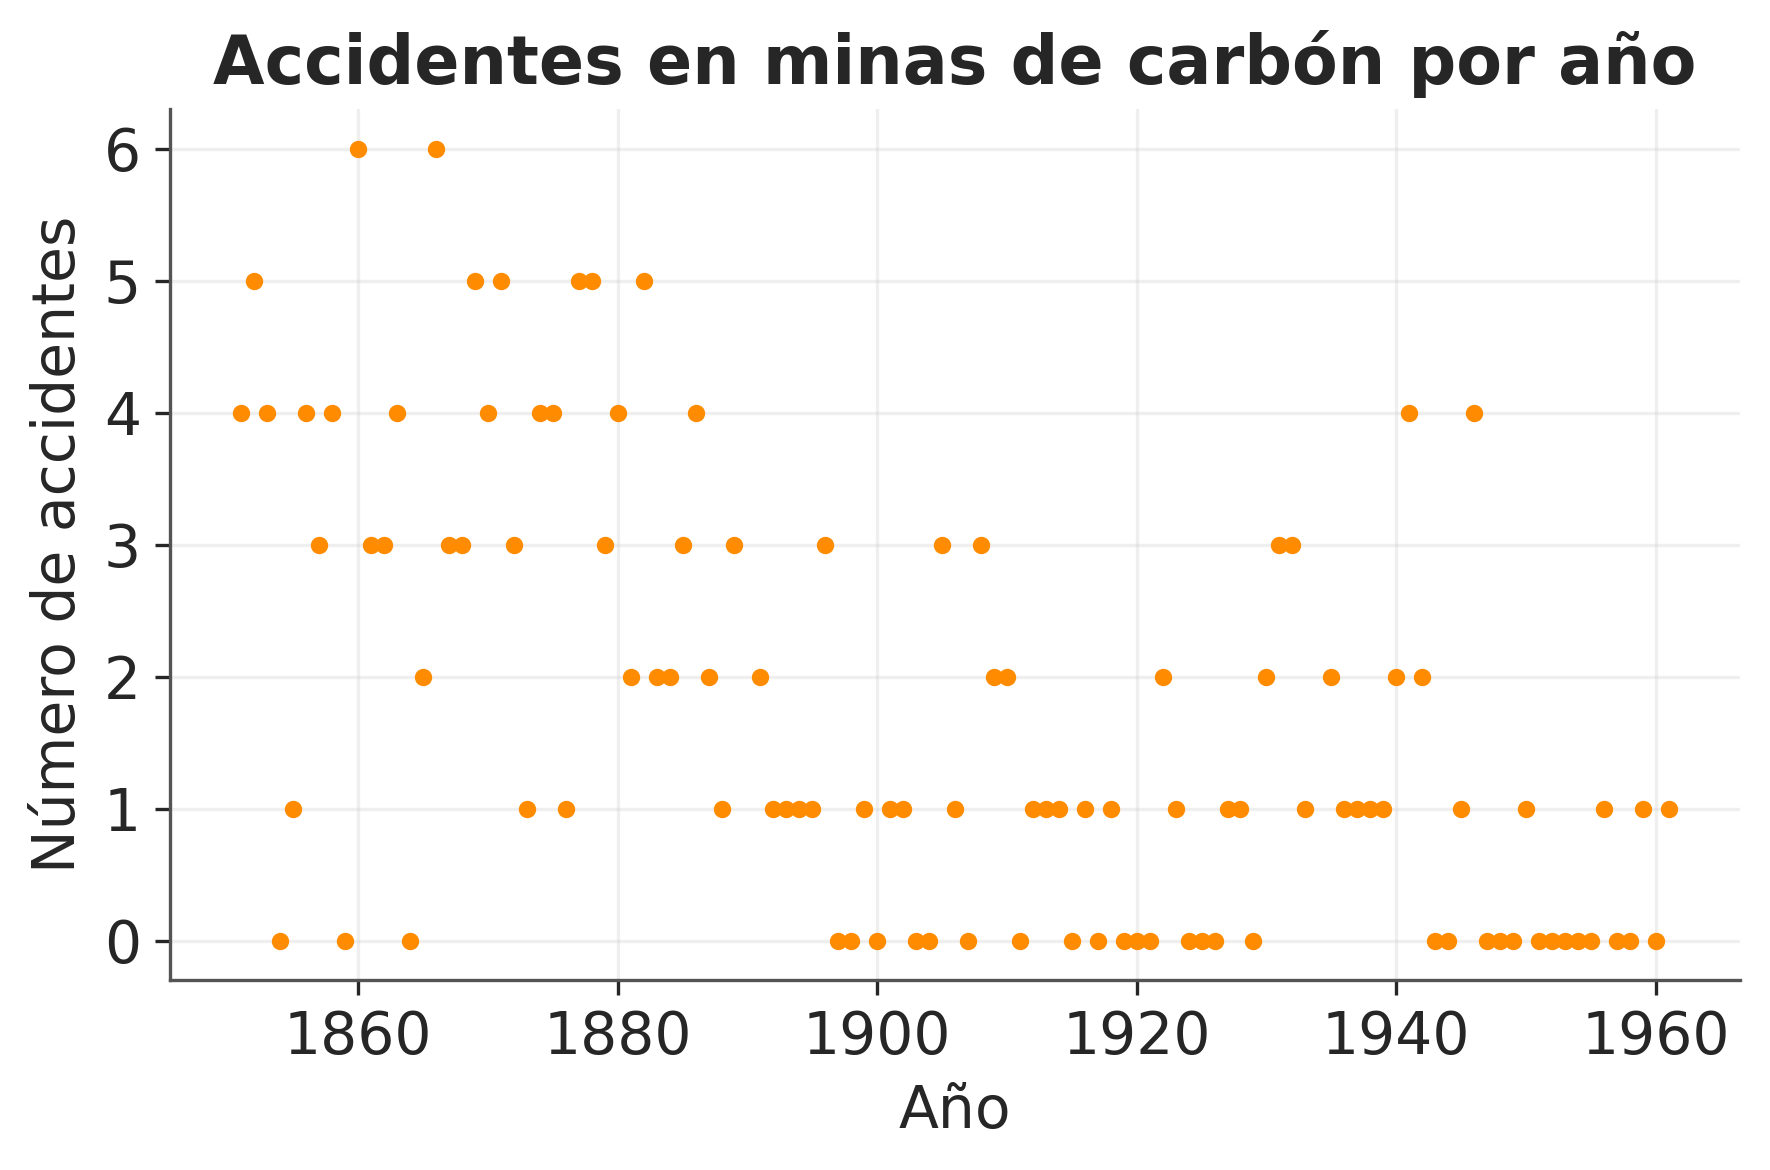

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(
    años,
    accidentes,
    color="darkorange",
    s=10
)

plt.xlabel("Año")
plt.ylabel("Número de accidentes")
plt.title("Accidentes en minas de carbón por año")
plt.grid(alpha=0.3)
plt.tight_layout()

**Creación del modelo:**

trabajaremos con una distribución de Poisson, y teniendo en cuenta que creemos que la cantidad media de accidentes es distinta antes y después de la introducción de regulaciones de seguridad, debemos incluir de alguna manera esta diferencia:

planteamos dos tasas medias de accidentes distitnas, que llamamos $t_0$ y $t_1$, y la estimación del punto de corte $p_{c}$ que nos perimitirá dividir los años para los cuales se aplica la tasa de accidentes $t_0$ de los cuales se aplica la tasa $t_1$.

El modelo nos queda:

\begin{equation}
A_t \sim Poisson(tasa)
\end{equation}

\begin{equation}
tasa = \begin{cases}
t_0, \text{si } t \ge pc,\\
t_1, \text{si } t \lt pc
\end{cases}
\end{equation}

con *priors*

\begin{align}
t_0 \sim Expon(1) \\
t_1 \sim Expon(1) \\
p_c \sim U(A_0, A_1)
\end{align}




Observación: la distribución uniforme es discreta y $A_0$ y $A_1$ son el primer y último año.

Ahora sí, pasamos a plantear nuestro modelo desde el punto de vista computacional usando PyMC:

In [ ]:
with pm.Model() as modelo_cat:

    pc = pm.DiscreteUniform("pc", lower=años.min(), upper=años.max())

    # Definimos los priors t0 y t1:
    t_0 = pm.Exponential("t_0", 1)
    t_1 = pm.Exponential("t_1", 1)

    # Asignamos las tasas a los años de acuerdo al p_c:
    tasa = pm.Deterministic("tasa", pm.math.switch(pc <= años, t_1, t_0))

    acc = pm.Poisson("acc", tasa, observed=accidentes)
    idata_cat = pm.sample(1000, random_seed=1791, idata_kwargs={"log_likelihood": True})

/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1304: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1318: ImputationWarning: Data in acc contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Observación: la función `pm.switch`nos indica que si el argumento es _True_ nos va a devolver el segundo argumento, si es _False_ nos devolverá el tercer argumento.


In [ ]:
idata_cat # verificamos rápidamente que el muestreo se realizó correctamente y qué información quedó almacenada en el objeto.

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

El siguiente gráfico representa las distribuciones posteriores de los parámetros asociados a las tasas de accidentes antes y después del cambio en el modelo. A partir de las muestras obtenidas mediante MCMC, se visualiza la incertidumbre asociada a cada parámetro y el intervalo de máxima densidad (HDI) correspondiente. La comparación entre ambas distribuciones permite analizar si existe evidencia de una modificación en la tasa de accidentes luego de la implementación de las medidas de seguridad.

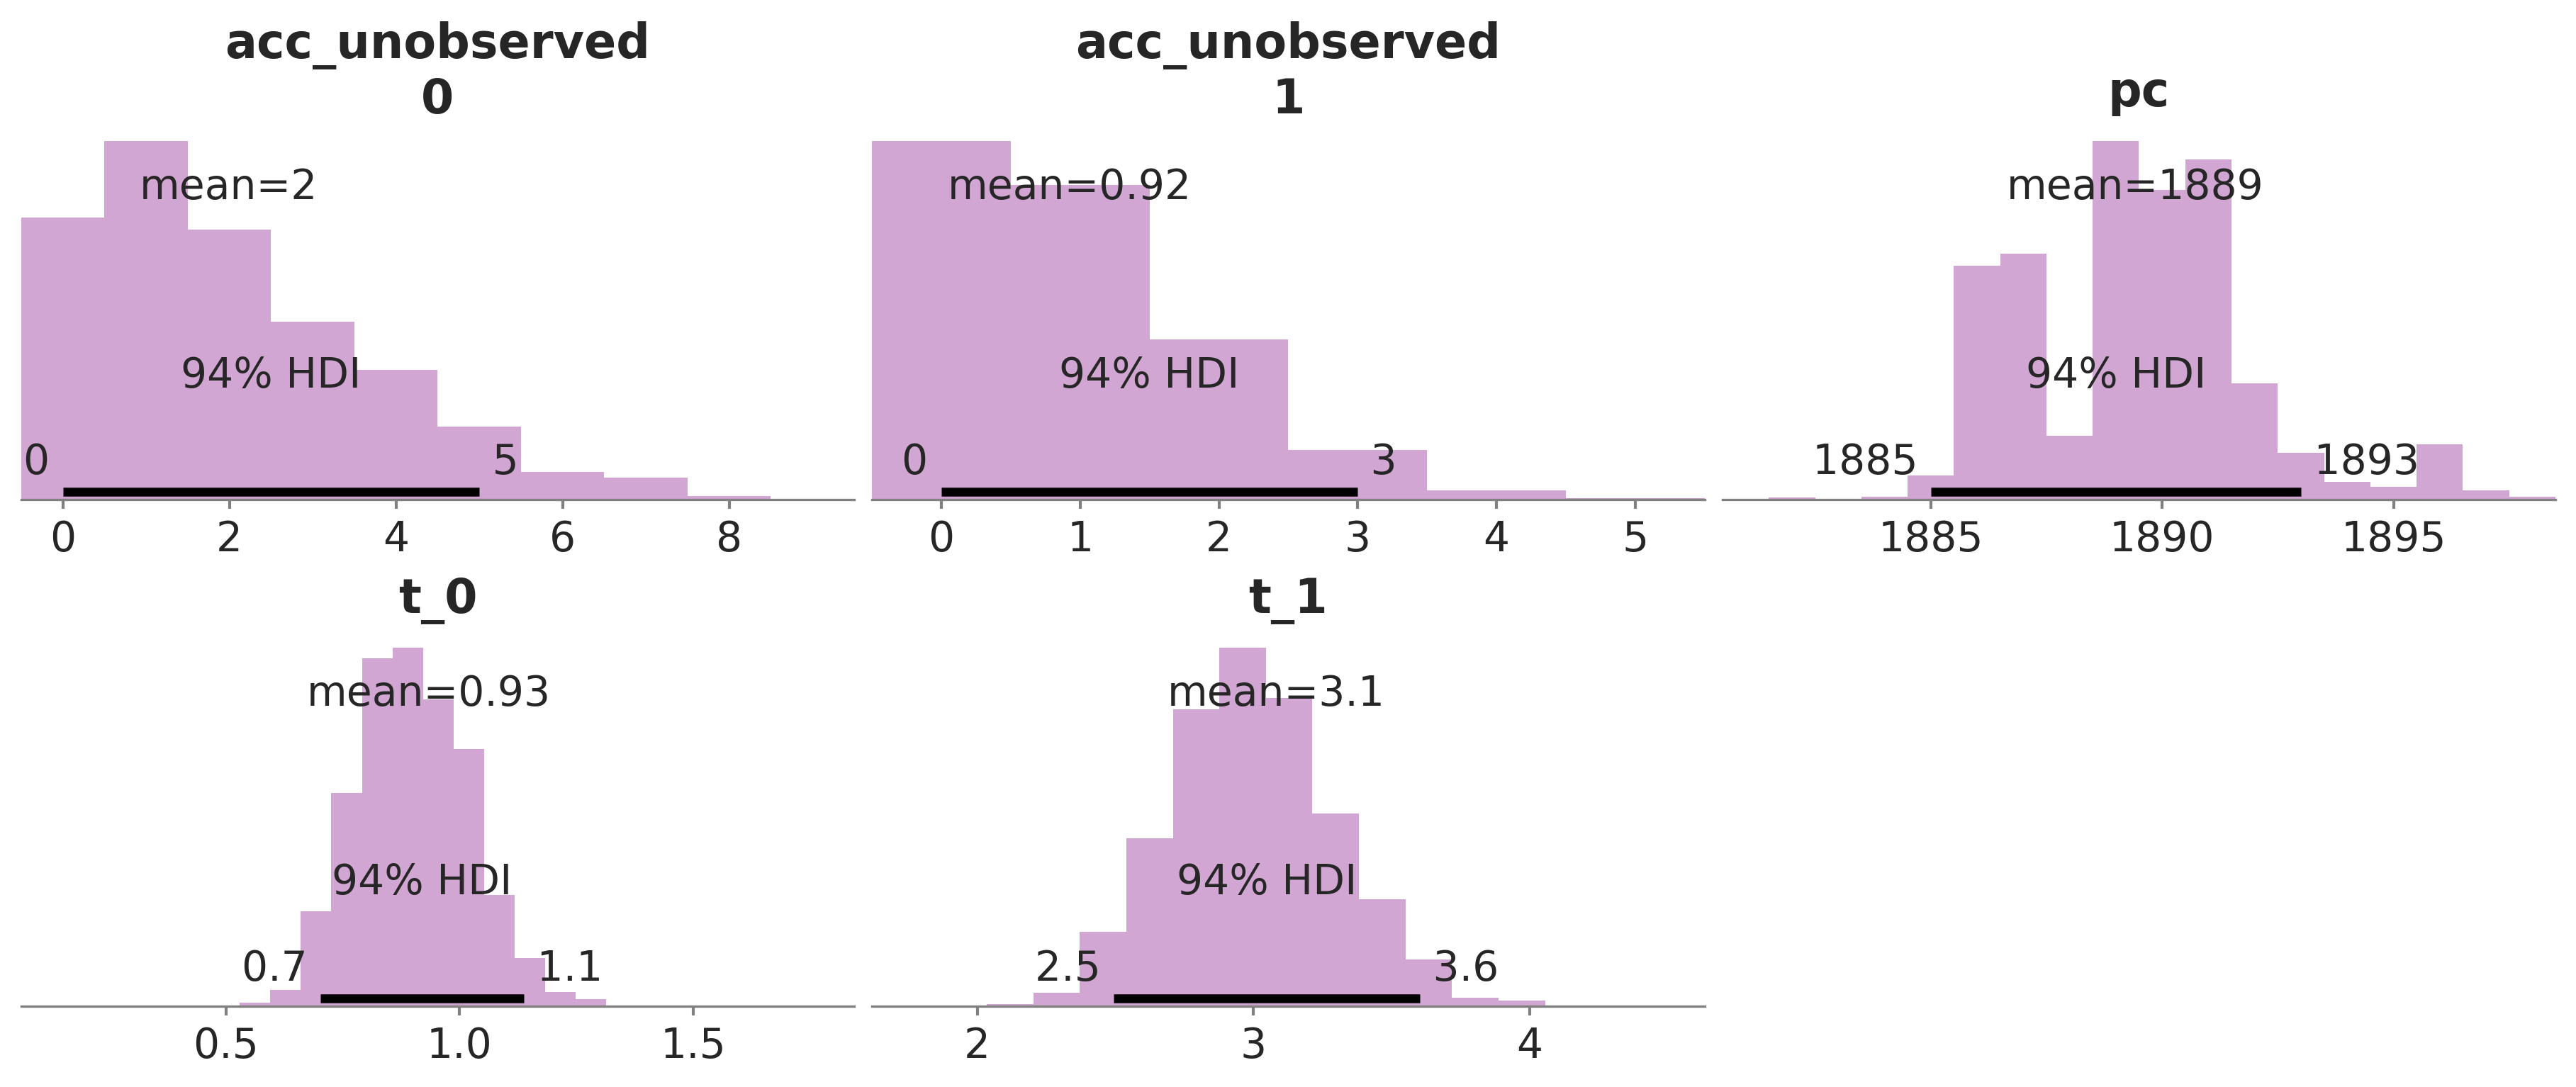

In [ ]:
az.plot_posterior(
    idata_cat,
    var_names=["~tasa", "~acc"],
    hdi_prob=0.94,
    figsize=(12, 5),
    point_estimate="mean",
    kind="hist",
    color="purple"
);

In [ ]:
az.summary(idata_cat, kind="stats", var_names=["~tasa", "~acc"])

,mean,sd,hdi_3%,hdi_97%
acc_unobserved[0],1.985,1.722,0.000,5.000
acc_unobserved[1],0.924,0.955,0.000,3.000
pc,1889.425,2.482,1885.000,1893.000
t_0,0.934,0.119,0.702,1.137
t_1,3.083,0.298,2.494,3.602


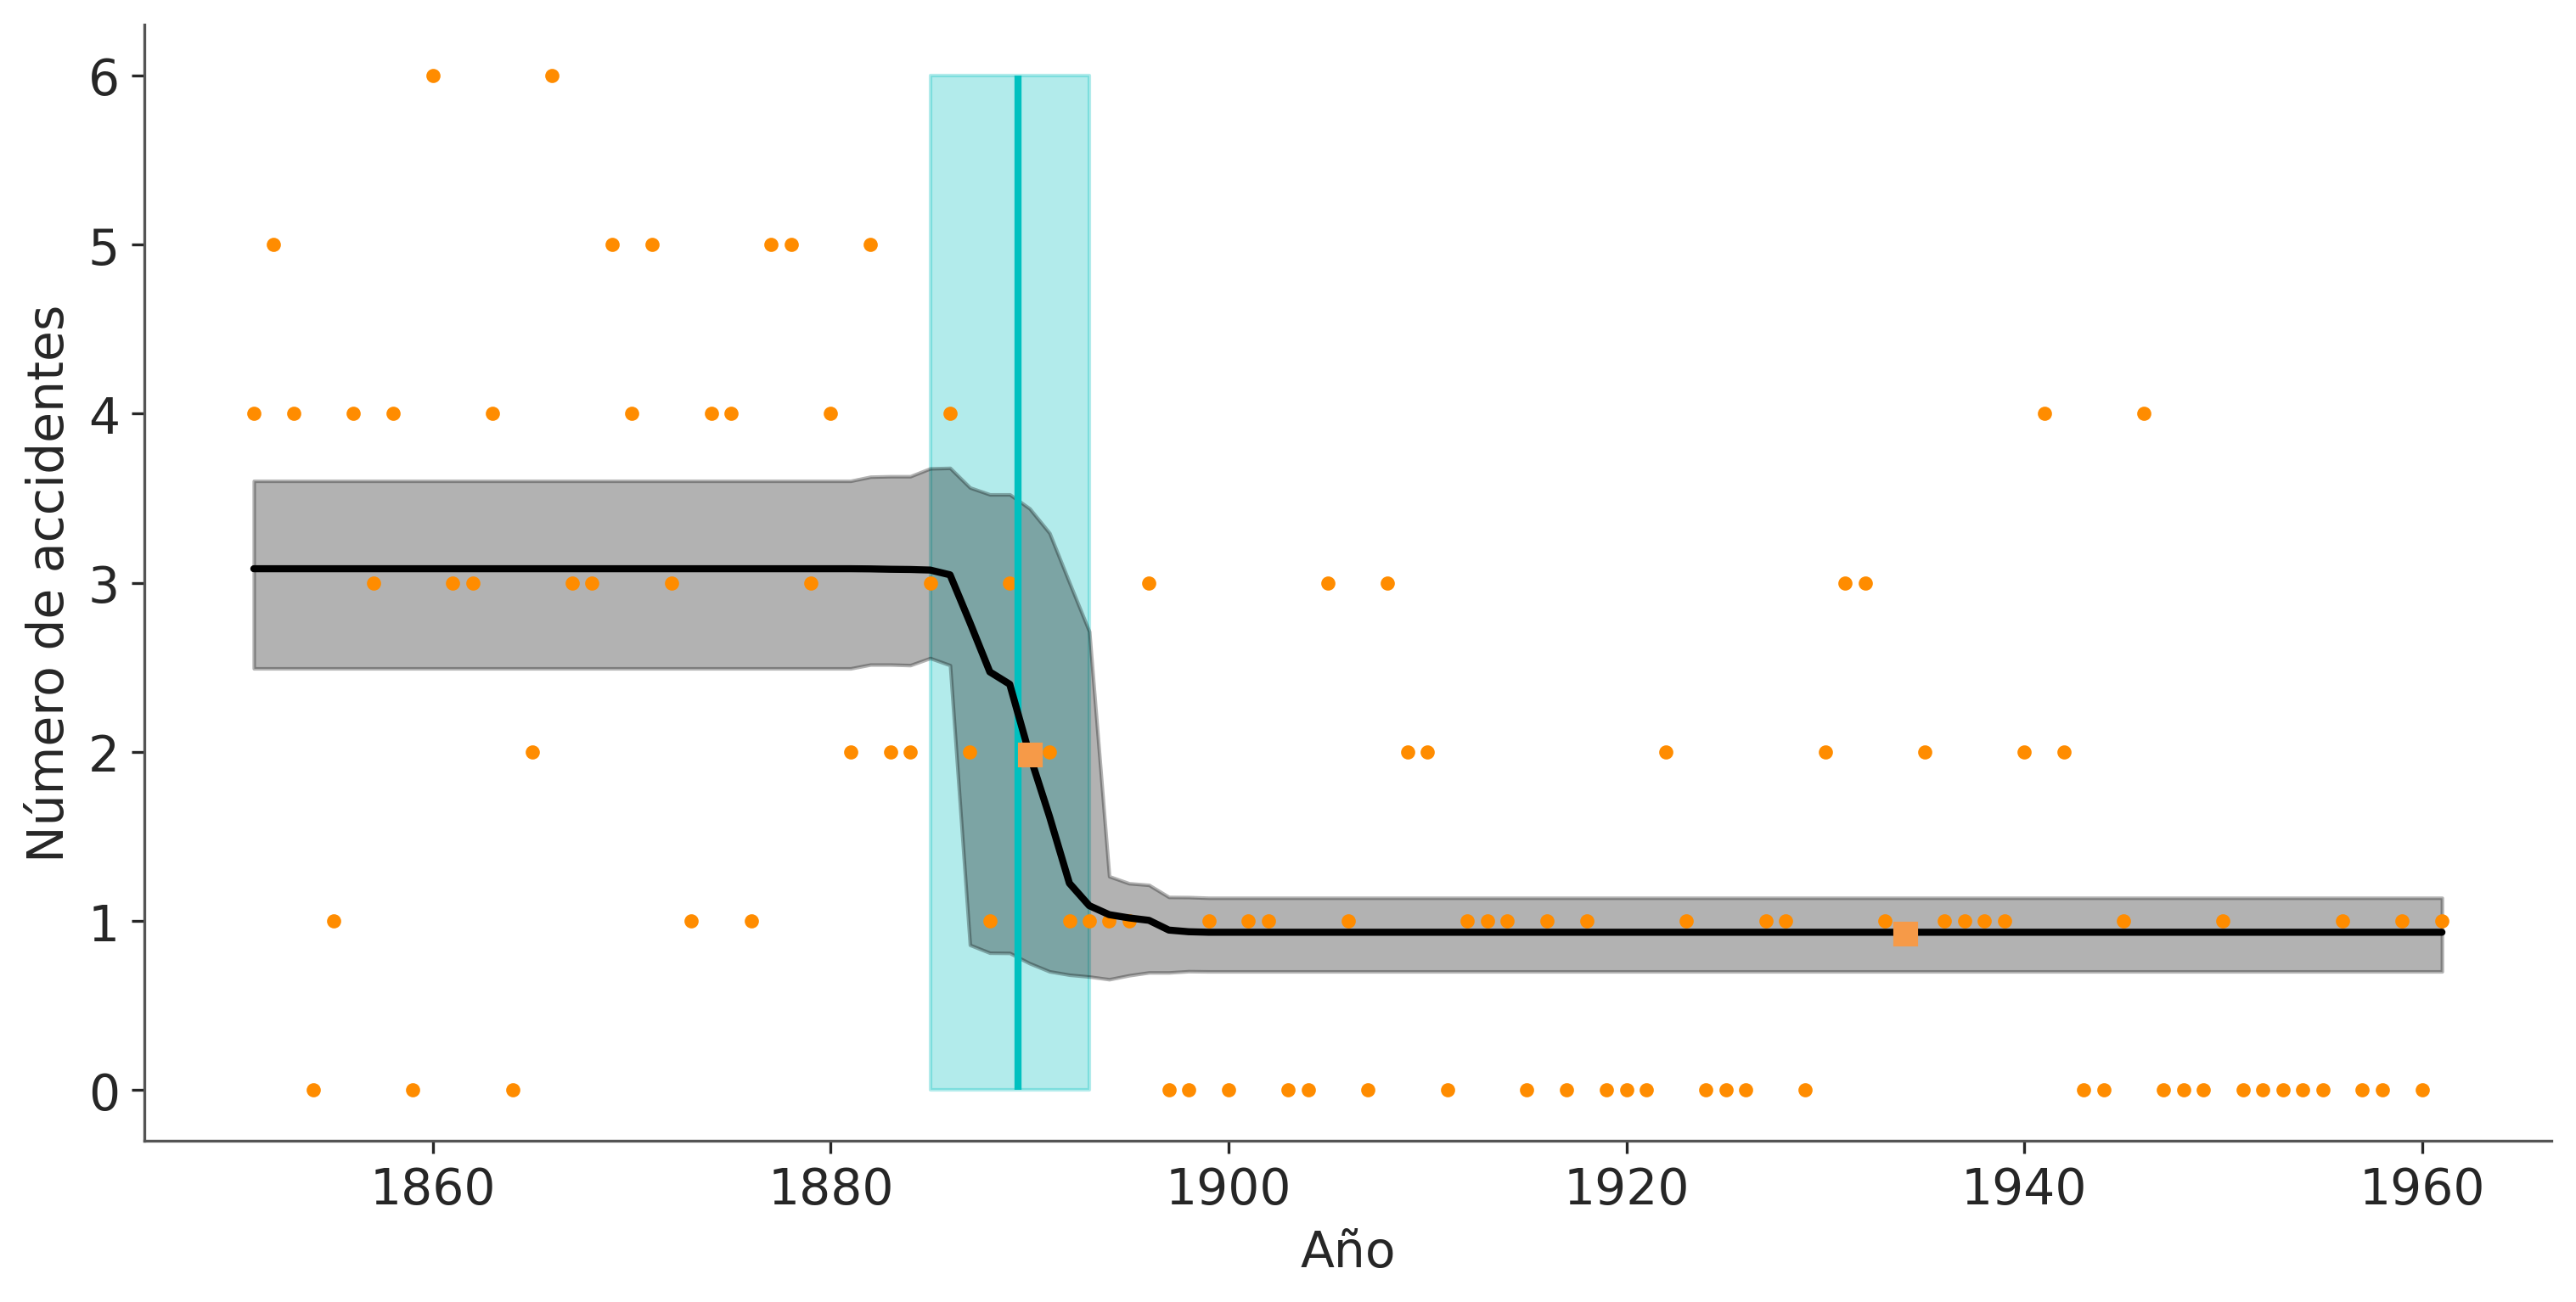

In [ ]:
tasa_mean = idata_cat.posterior["tasa"].mean(("chain", "draw"))
tasa_hdi = az.hdi(idata_cat.posterior["tasa"].values)
pc_hdi = az.hdi(idata_cat.posterior["pc"])["pc"]

_, ax = plt.subplots(figsize=(10, 5), sharey=True)
ax.plot(años, accidentes, ".", color="darkorange")

ax.set_ylabel("Número de accidentes")
ax.set_xlabel("Año")

ax.vlines(
    idata_cat.posterior["pc"].mean(("chain", "draw")),
    accidentes.min(),
    accidentes.max(),
    color="C1",
    lw=2,
)


ax.fill_betweenx(
    [accidentes.min(), accidentes.max()], pc_hdi[0], pc_hdi[1], alpha=0.3, color="C1"
)
ax.plot(años, tasa_mean, "k", lw=2)
ax.fill_between(años, tasa_hdi[:, 0], tasa_hdi[:, 1], alpha=0.3, color="k")


faltante0 = (
    idata_cat.posterior["acc_unobserved"].sel(acc_unobserved_dim_0=0).mean(("chain", "draw"))
)
faltante1 = (
    idata_cat.posterior["acc_unobserved"].sel(acc_unobserved_dim_0=1).mean(("chain", "draw"))
)

ax.plot(años[np.isnan(accidentes)], [faltante0, faltante1], "C2s");

**Observaciones:**

* Los puntos naranjas representan el número de accidentes observado para cada año.
* La línea negra muestra la tasa media estimada por el modelo. La banda gris representa su intervalo de credibilidad HDI, indicando los valores de tasa compatibles con el posterior.
* La línea vertical marca la estimación posterior de pc, mientras que la franja vertical muestra su HDI.
* Los cuadrados verdes corresponden a los accidentes de los años cuyos datos estaban faltantes: no son observaciones, sino valores estimados por el modelo, obtenidos de la distribución posterior de acc_unobserved.

---> Entonces: el gráfico nos permite ver cómo el modelo reconstruye la evolución de la tasa de accidentes a lo largo del tiempo, cuantifica la incertidumbre de esas estimaciones y completa los años con información faltante. **¡La idea importante es que no se muestra solamente una estimación puntual, sino también qué tan incierta es esa estimación!**

## **Comparación de grupos**

En muchas ocasiones, es necesario realizar una comparación de grupos. Cuando hacemos análisis de datos, nos puede interesar hacer un análisis "diferenciado", por ejemplo en la efectividad de una droga en un tratamiento médico vs un grupo de control, etc.

Un primer paso para abordar esta problemática, es seleccionar las características que vamos a utilizar, como suele ser la media de cara grupo, y a partir de eso realizar cálculos como el de la distribución _a posteriori_ de la diferencia entre medias.

### <font color="pink"> **d de Cohen**

El ***d de Cohen*** es una medida que nos permitirá cuantificar el tamaño del efect, seǵun la siguiente fórmula:

$$\frac{\mu_2 - \mu_1}{\sqrt{\frac{\sigma_2^2 + \sigma_1^2}{2}}}$$


donde se observa que se combina la desviación estándar de ambos grupos involucrados. Es decir, el d de Cohen es una forma de medir el tamaño del efecto, donde la diferencia de las medias resulta estandarizarse al considerar dicha combinación.

* Veamos ciertas consideraciones a la hora de calcular una distribución _a posteriori_ de los valores d de Cohen:

1. una primera observación es que la fórmula anterior no considera el tamaño de la muestra, pues estamos tomamos estos valores de cada grupo mediante el _posterior_. <font color="pink"> Esto ya nos dice que se considera la incertidumbre de las desviaciones estándar). </font>

2. El coeficiente d de Cohen estandariza la diferencia entre dos grupos utilizando su variabilidad, medida a través de las desviaciones estándar. De esta manera, la magnitud de la diferencia se interpreta en relación con la dispersión de los datos y no únicamente por su valor absoluto. Esto facilita comparar resultados y evaluar la importancia práctica del efecto, incluso cuando las mediciones se encuentran en distintas escalas.

3. El d de Cohen puede interpretarse de forma similar a un *"Z-score"*, ya que expresa la diferencia entre dos medias en unidades de desviación estándar. Por ejemplo, un d=−1.2 indica que la media de un grupo se encuentra 1.2 desviaciones estándar por debajo de la media del otro grupo.

4. IEs necesario aclarar que no existe una receta única para determinar si el valor del d de Cohen es _grande_, _pequeño_, _mediano_, _importante_ o _despreciable_. Por ejemplo, un rango de 0.8 a 1.2 es el estándar, por lo que si nuestro coeficiente toma un valor igual a 2 podría significar algo inusual para nuestro experimento, inusual y es mejor realizar otro tipo de verificaciones.




### <font color="pink"> Probabilidad de superioridad


La Probabilidad de superioridad es aquella asociada a que un dato tomado al azar de un grupo tenga un valor mayor que un punto tomado al azar del otro grupo, es decir, nos indica una especie de comparación entre ambos puntos. Si asumimos que los datos se distribuyen de forma Gaussiana, podemos calcular la probabilidad de superioridad a partir de la d de Cohen mediante la expresión:

$$ps = \Phi \left ( \frac{d}{\sqrt{2}} \right)$$


tal que $\Phi$ es la distribución normal acumulada y $d$ es el d de Cohen que estudiamos antes. Si no estamos de acuerdo con la suposición de normalidad, podemos realizar los cálculos a partir del _posterior_.

### El conjunto de datos _propinas_


Para explorar el tema de esta sección, vamos a usar el conjunto de datos tips (propinas). Estos datos fueron informados por primera vez por Bryant, P. G. and Smith, M (1995) _Practical Data Analysis: Case Studies in Business Statistics_.

Queremos estudiar el efecto del día de la semana sobre la cantidad de propinas en un restaurante. Para este ejemplo, los diferentes grupos son los días. Comencemos el análisis cargando el conjunto de datos como un DataFrame de Pandas usando solo una línea de código. Si no está familiarizado con Pandas, el comando _tail_ se usa para mostrar las últimas filas de un DataFrame:

In [ ]:
tips = pd.read_csv("propinas.csv")
tips.tail()

Para este ejemplo solo vamos a usar las columnas `dia` y `propina` y vamos a usar la función `plot_forest` de ArviZ. Aún cuando ArviZ está pensado para análisis de modelos Bayesianos algunos de sus funciones pueden ser útiles para analizar datos.

**Este código utiliza** ArviZ para visualizar la distribución de propinas para cada día de la semana, usando un **ridgeplot**. El gráfico muestra las densidades de probabilidad de las propinas para cada día, lo que permite una comparación visual rápida.

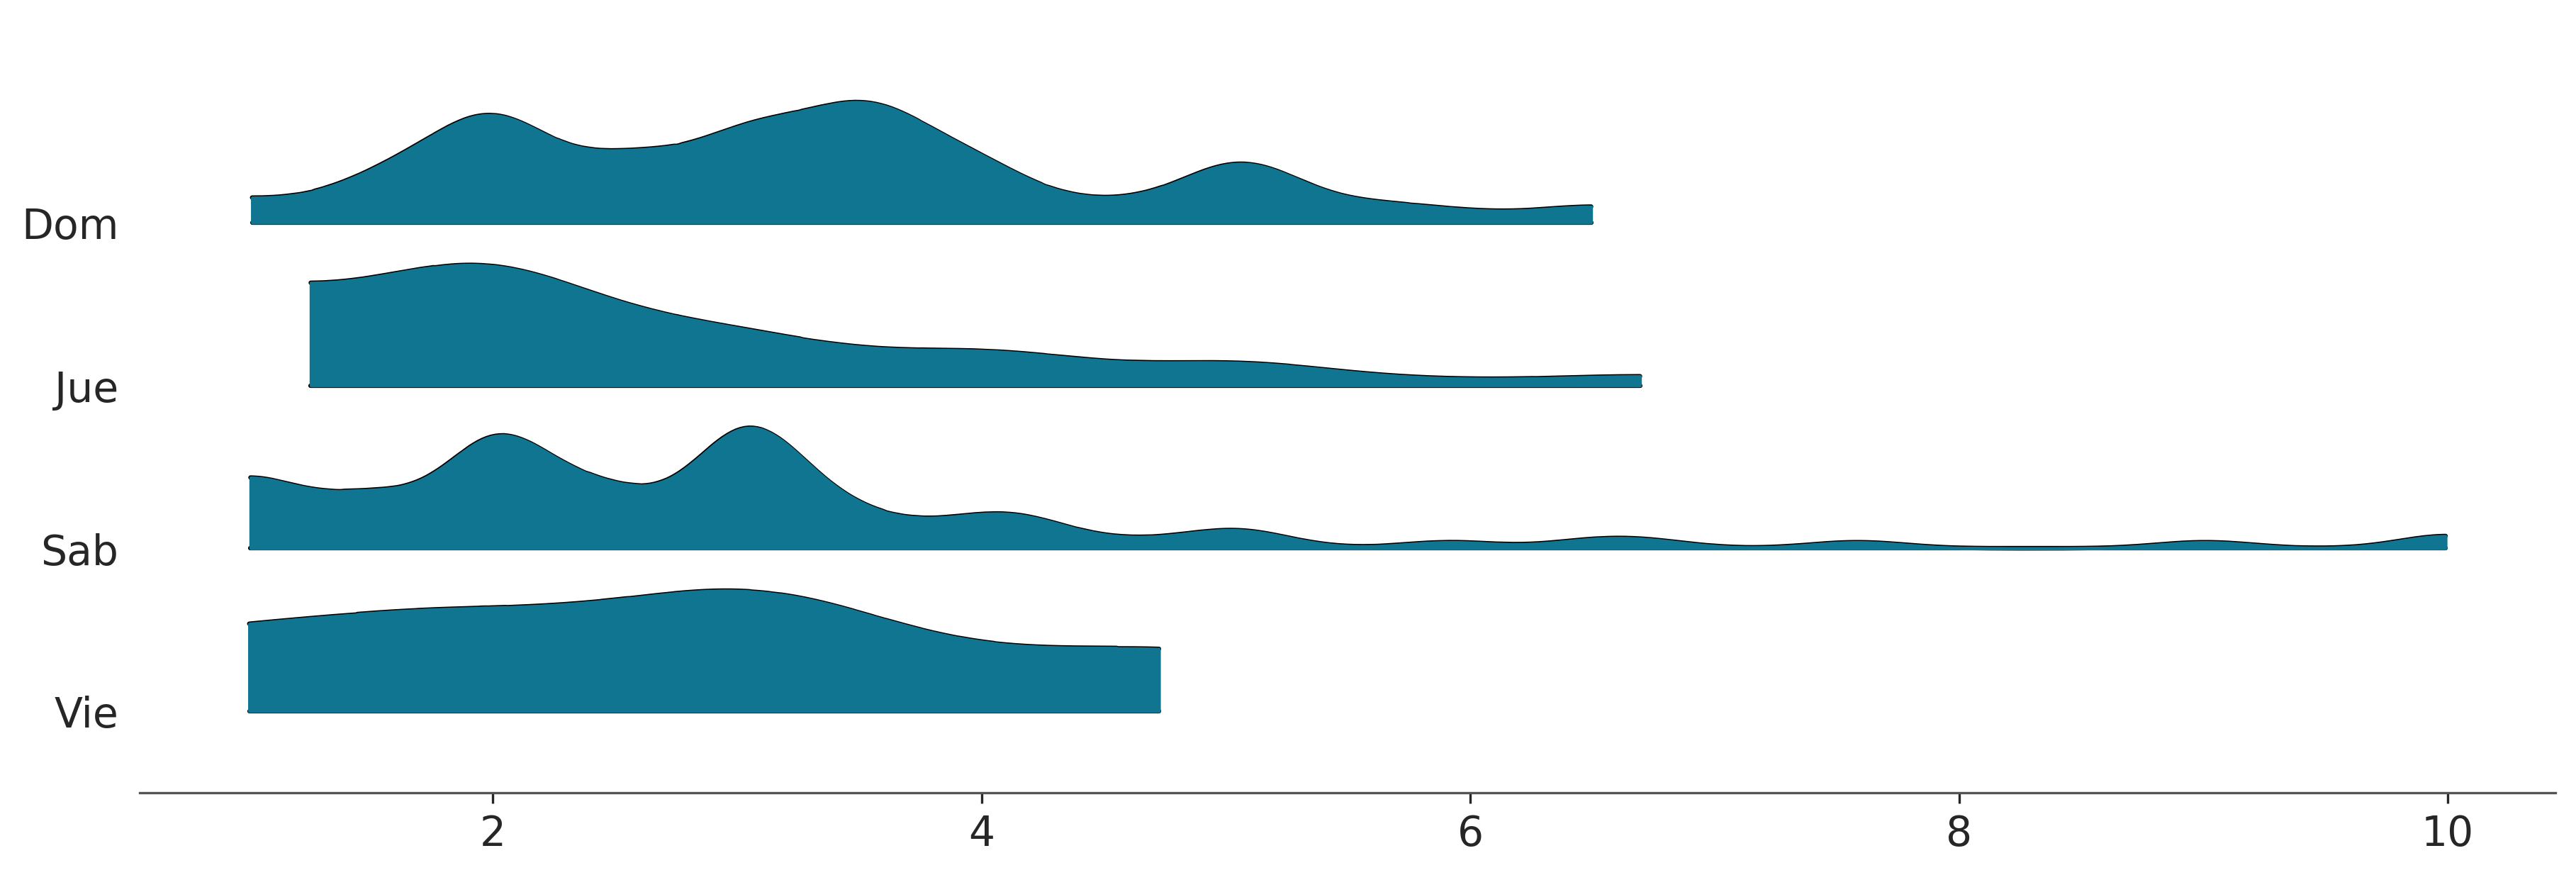

In [ ]:
az.plot_forest(
    tips.pivot(columns="dia", values="propina").to_dict("list"),
    kind="ridgeplot",
    hdi_prob=1,
    figsize=(12, 4),
);

A fin de simplificar el análisis vamos a crear 2 variables:
* La variable `categories` contiene los nombres de los días (abreviados)
* La variable `idx` codifica los días de la semana como enteros entre 0 y  3.

In [ ]:
categories = np.array(["Jue", "Vie", "Sab", "Dom"])

tip = tips["propina"].values
idx = pd.Categorical(tips["dia"], categories=categories).codes

Para este modelo necesitamos definir 4 grupos, uno por cada dia. Supongamos que cada grupo lo queremos representar como una distribución Gamma con media $\mu$ y desviación estándar $\sigma$ (recordemos que se modeliza con distribuciones Gamma porque son una opción natural para variables que solo pueden tomar valores positivos y que a menudo tienen una distribución asimétrica, como es el caso de la propina. Además, en el contexto bayesiano, la Gamma es un prior conjugado para el parámetro de tasa de una distribución de Poisson, lo que simplifica los cálculos de la posterior). En ese caso vamos a necesitar definir 4 medias y 4 desviaciones estándar. Una versión `naive` sería escribir 8 distribuciones a priori. Algo como esto:

```python
with pm.Model() as comparación_grupos:
    μ0 = pm.Normal('μ0', mu=0, sigma=5)
    μ1 = pm.Normal('μ1', mu=0, sigma=5)
    μ2 = pm.Normal('μ2', mu=0, sigma=5)
    μ3 = pm.Normal('μ3', mu=0, sigma=5)
    σ0 = pm.HalfNormal('σ0', sigma=1)
    σ1 = pm.HalfNormal('σ1', sigma=1)
    σ2 = pm.HalfNormal('σ2', sigma=1)
    σ3 = pm.HalfNormal('σ3', sigma=1)
    
    ....
```

Esto es sintáticamente posible y semánticamente correcto (es lo que hicimos en el modelo de los accidentes mineros). Pero repetir código es en general una muy mala práctica que dificulta la lectura del código/modelo y dificulta hacer cambios a futuro. Una forma de no repetir código es escribir `for loops`. Pero en PyMC (como en NumPy y otras librerías de Python) lo que conviene es vectorizar el código. Para ello podemos especificar el argumento `shape` para los priors $\mu$ y $\sigma$. El modelo completo nos quedaría de la siguiente manera:

```python
with pm.Model() as comparing_groups:
    μ = pm.Normal('μ', mu=0, sigma=5, shape=4)
    σ = pm.HalfNormal('σ', sigma=1, shape=4)
    
    y = pm.Gamma("y", mu=μ[idx], sigma=σ[idx], observed=tip)
```

Es importante notar que estamos especificando 4 valores independiente de $\mu$ y cuatro valores independientes de $\sigma$ y que $\mu$ y $\sigma$ son vectores de dimensión 4.Fijensé que para el likelihood usamos la variable `idx` para indexar de forma adecuada $\mu$ y $\sigma$ para asegurar que usamos los parámetros correctos para cada grupo.

Usar shapes es correcto, pero PyMC provee una sintaxis alternativa que a veces es más conveniente. Esta sintaxis consiste en especificar coordenadas y dimensiones. La ventaja de esto es que permite una mejor integración con ArviZ. Veamos, en este ejemplo tenemos 4 valores para las medias y 4 para las desviaciones estándar, y por eso usamos `shape=4`. El InferenceData tendrá 4 indices `0, 1, 2, 3` correspondientes a cada uno de los 4 días. Pero es trabajo del usuario asociar esos indices numéricos con los días. En cambio al usar coordenadas y dimensiones nosotros podremos usar los rótulos `'Jue', 'Vie', 'Sab', 'Dom'` para referirnos a los parámetros relacionados con cada uno de estos días. ArviZ también podrá hacer uso de estos rótulos. Referirse a "rotulos" y no a indices, suele ser más simple y contribuye a evitar errores.

Vamos a especificar dos coordenadas `dias` con las dimensiones `'Jue', 'Vie', 'Sab', 'Dom'` y `dias_flat` que contendrá los mismo rótulos pero repetidos según el orden y longitud que corresponda con cada observación. Esto último será útil para poder obtener pruebas predictivas a posteriori para cada día.

In [ ]:
coords = {"dias": categories, "dias_flat": categories[idx]}

with pm.Model(coords=coords) as comparing_groups:
    μ = pm.HalfNormal("μ", sigma=5, dims="dias")
    σ = pm.HalfNormal("σ", sigma=1, dims="dias")

    y = pm.Gamma("y", mu=μ[idx], sigma=σ[idx], observed=tip, dims="dias_flat")

    idata_cg = pm.sample()
    idata_cg.extend(pm.sample_posterior_predictive(idata_cg))

Output()

Output()

Una vez obtenido un  _a posteriori_ podemos hacer todos los análisis que creamos pertinentes con el. Primero hagamos una prueba predictiva a posteriori. Vemos que en general somos capaces de capturar la forma general de las distribuciones, pero hay detalles que se nos escapan. Esto puede deberse al tamaño relativamente pequeño de la muestra, a que hay otros factores además del día que tienen influencia en las propinas o una combinación de ambas. Por ahora seguiremos con el análisis considerando que el modelo es lo suficientemente bueno

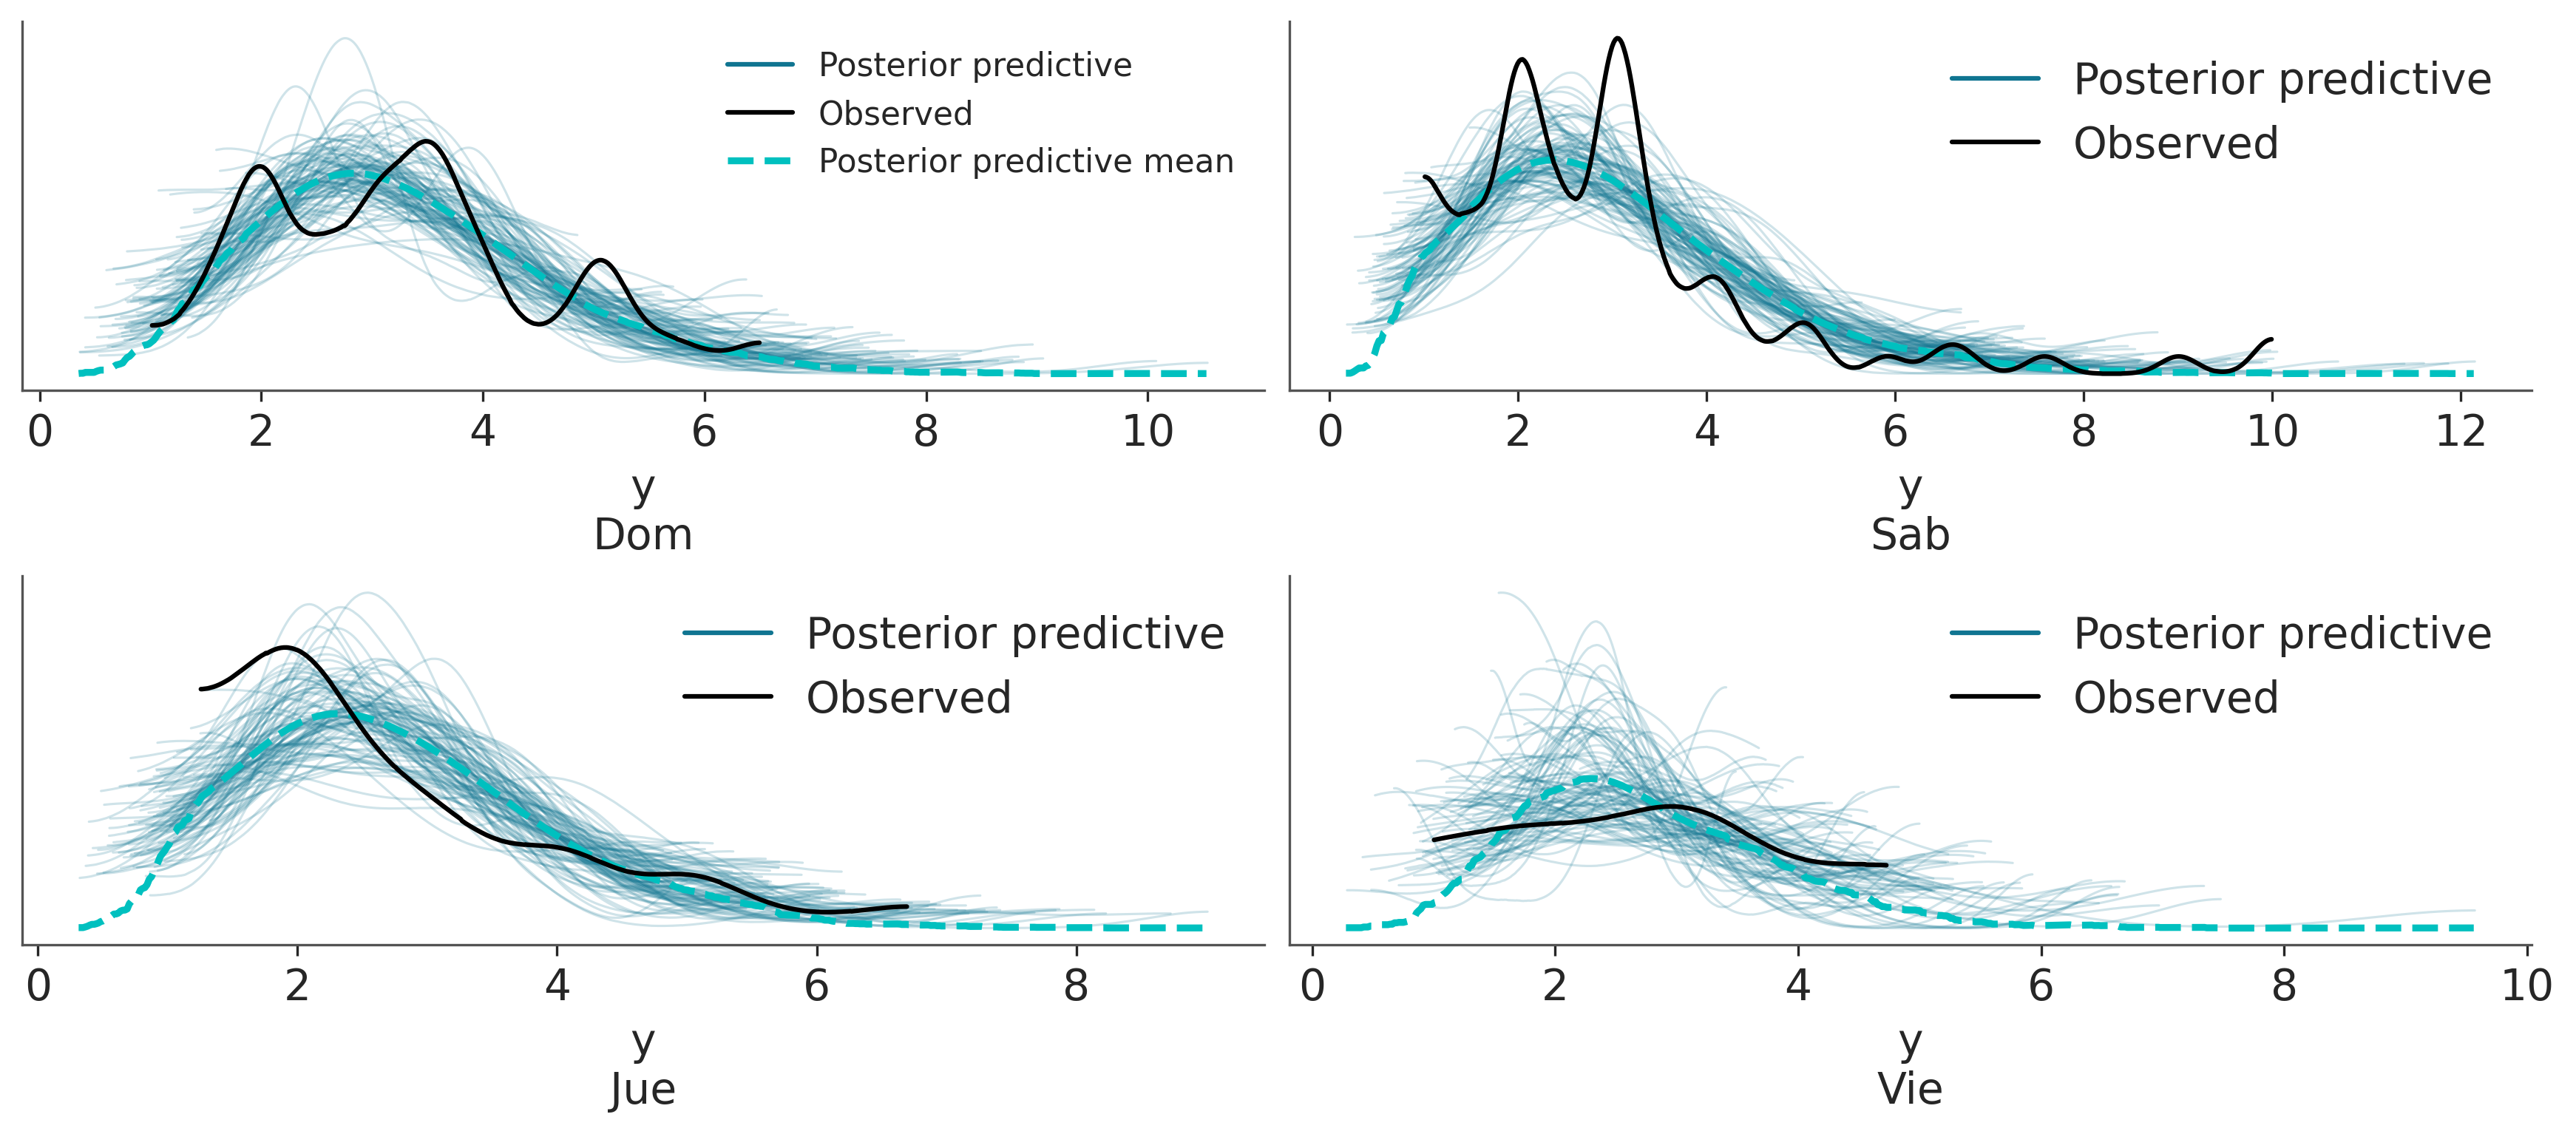

In [ ]:
_, axes = plt.subplots(2, 2)
az.plot_ppc(
    idata_cg,
    num_pp_samples=100,
    coords={"dias_flat": [categories]},
    flatten=[],
    ax=axes,
);

Podemos ver la distribución de cada uno de los parámetros haciendo

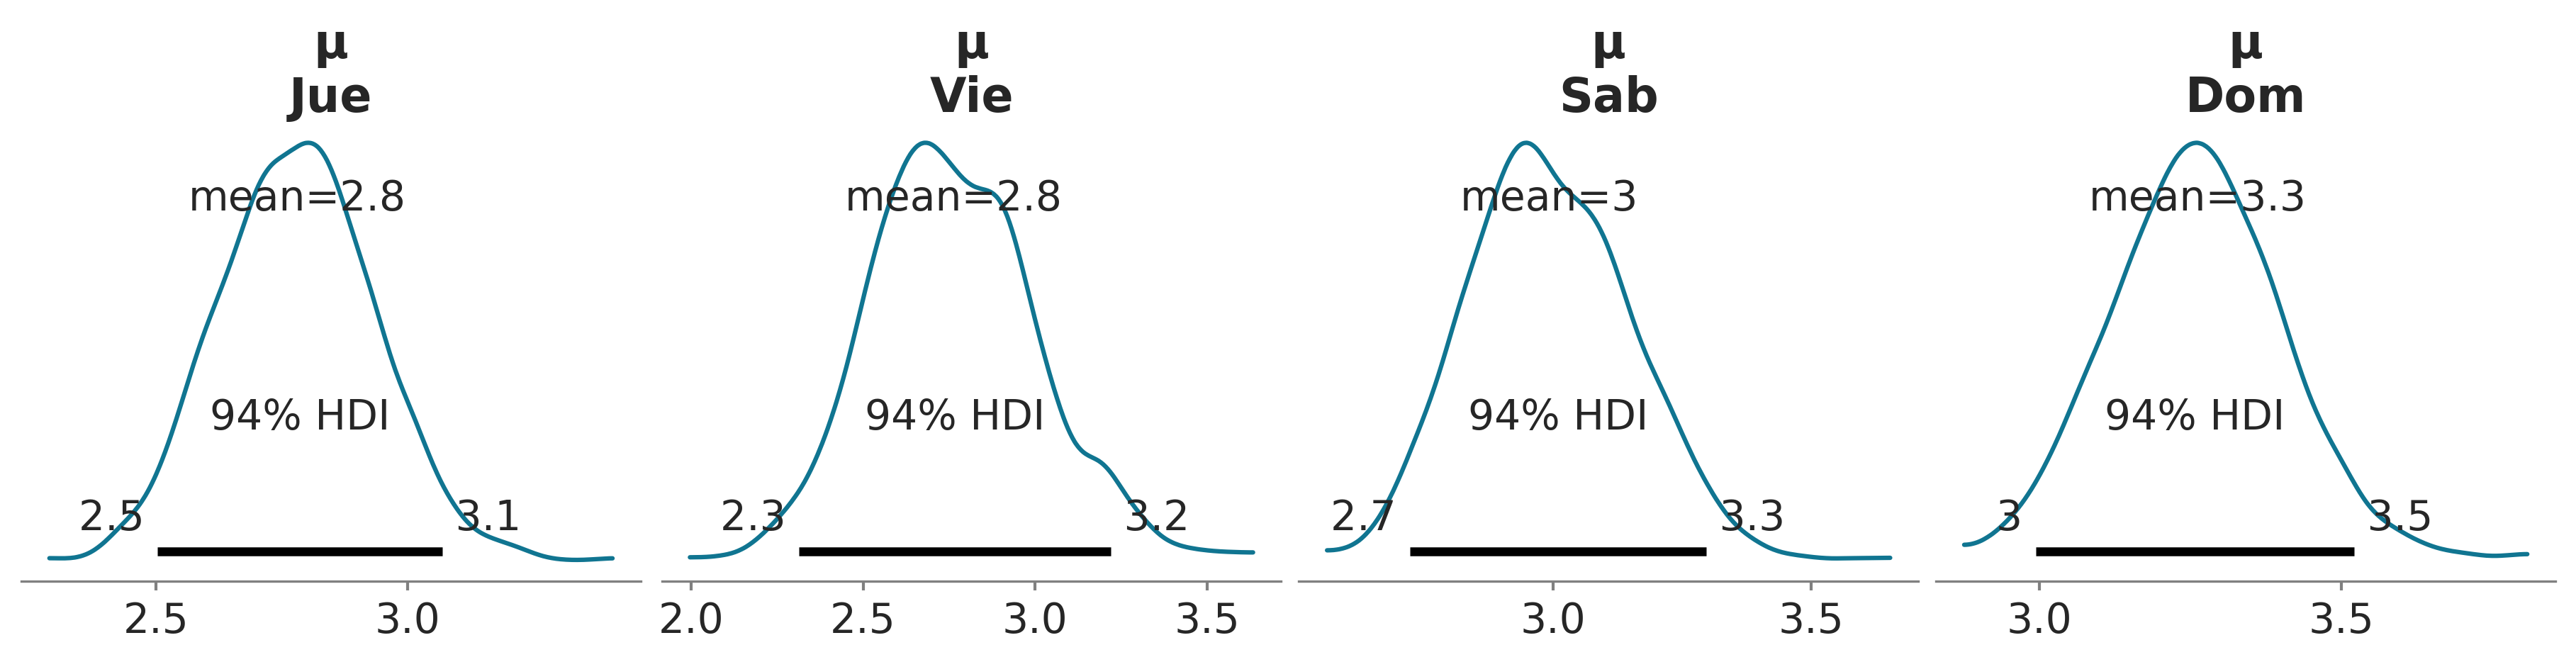

In [ ]:
az.plot_posterior(idata_cg, var_names="μ", figsize=(12, 3));

La figura anterior nos permite obtener bastante información. Por ejemplo, podemos observar que los valores medios de las propinas son muy similares entre los distintos días de la semana, aunque el domingo presenta una media ligeramente superior al resto.

Sin embargo, puede resultar más útil comparar los días directamente entre sí. Para ello, podemos calcular todas las diferencias de medias a posteriori y representar sus distribuciones. Además, podemos complementar estas diferencias con medidas de tamaño del efecto que sean fácilmente interpretables, como la d de Cohen o la probabilidad de superioridad.

**d de Cohen:**

La d de Cohen estandariza la diferencia entre las medias utilizando la variabilidad de los grupos:

$$
\frac{\mu_2 - \mu_1}{\sqrt{\frac{\sigma_1^2 + \sigma_2^2}{2}}}
$$


Puede interpretarse de manera similar a un z-score: indica cuántas desviaciones estándar se encuentra la media de un grupo por encima o por debajo de la media del otro.

**Probabilidad de superioridad**

La probabilidad de superioridad representa la probabilidad de que un valor seleccionado al azar de un grupo sea mayor que un valor seleccionado al azar del otro grupo.

Si suponemos que los datos siguen una distribución normal, podemos obtenerla a partir de la d de Cohen:


$$
\text{ps} = \Phi \left ( \frac{\delta}{\sqrt{2}} \right)
$$


donde $\Phi$ es la función de distribución acumulada (CDF) de una distribución normal estándar.

Finalmente, podemos utilizar plot_posterior para visualizar las diferencias entre los distintos días. Solo calculamos las comparaciones que aportan información nueva: no incluimos la diferencia de un día consigo mismo y tampoco repetimos comparaciones equivalentes, como Vie − Jue si ya hemos calculado Jue − Vie.

Si imagináramos todas las comparaciones como una matriz de diferencias, estaríamos mostrando únicamente una de sus dos mitades triangulares, ya que la otra contiene exactamente la misma información con el signo invertido.

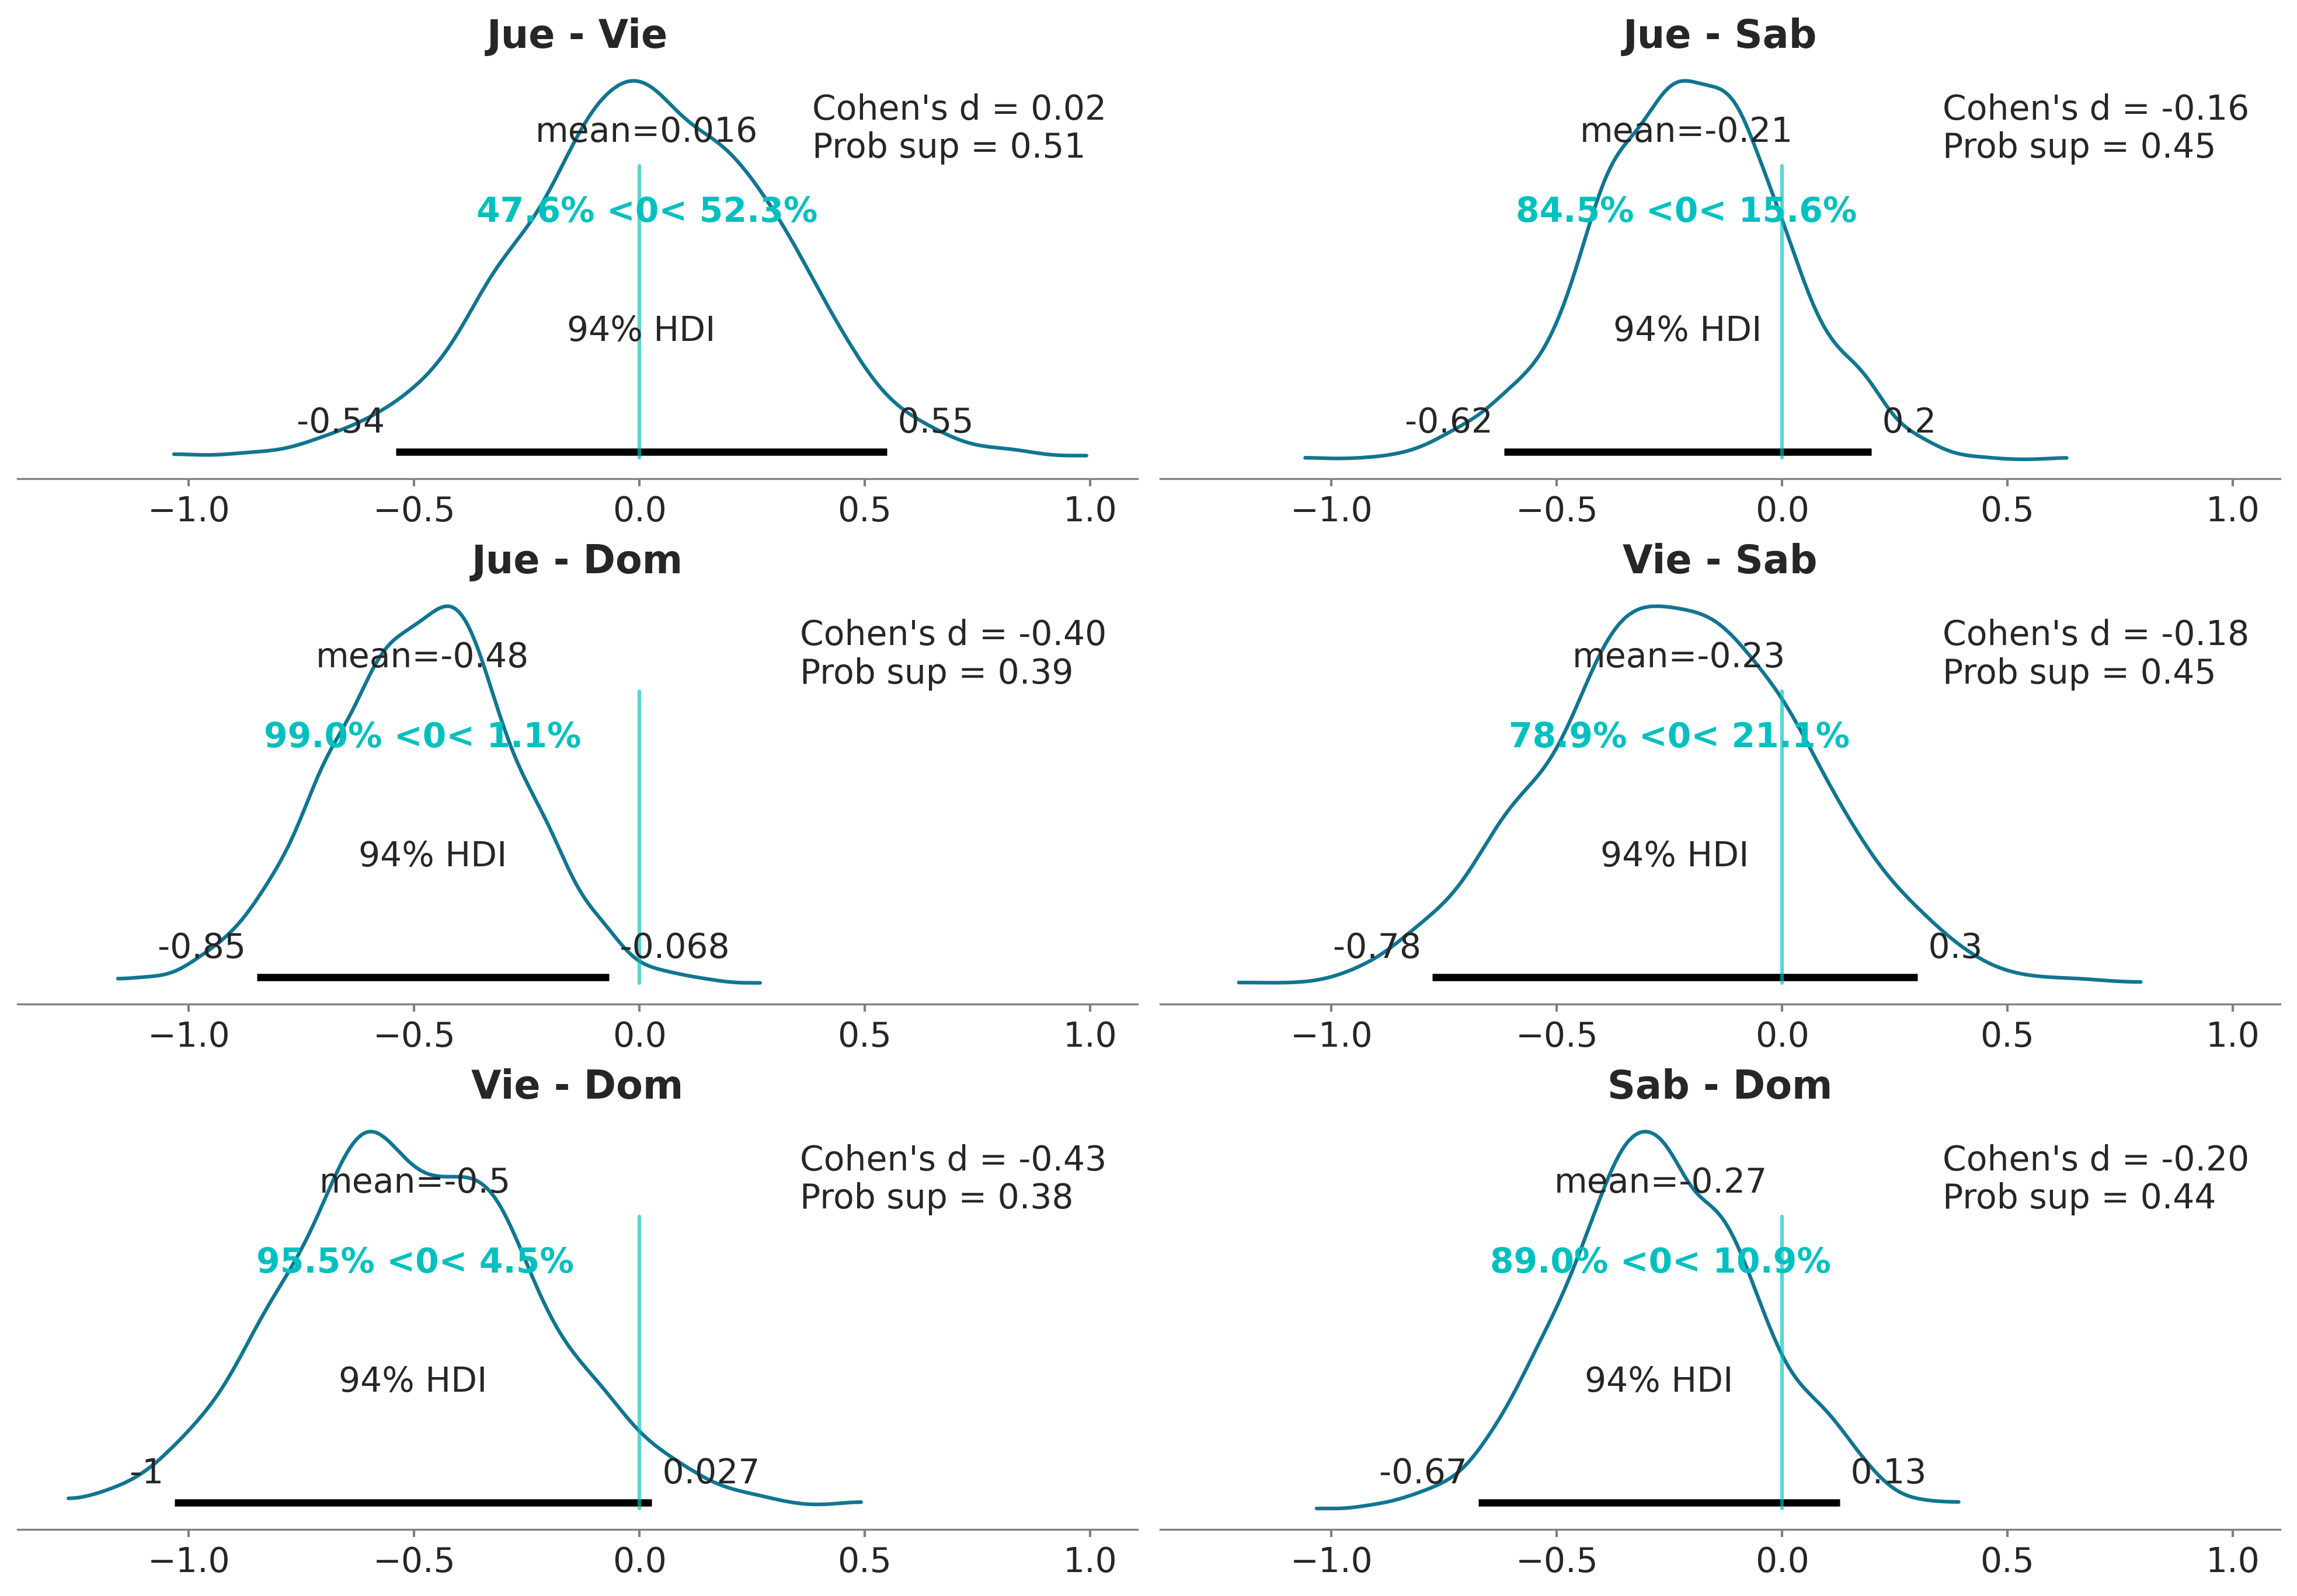

In [ ]:
cg_posterior = az.extract(idata_cg)

dist = pz.Normal(0, 1)

comparisons = [(categories[i], categories[j]) for i in range(4) for j in range(i+1, 4)]

_, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)

for (i, j), ax in zip(comparisons, axes.ravel()):
    means_diff = cg_posterior["μ"].sel(dias=i) - cg_posterior['μ'].sel(dias=j)

    d_cohen = (means_diff /
               np.sqrt((cg_posterior["σ"].sel(dias=i)**2 +
                        cg_posterior["σ"].sel(dias=j)**2) / 2)
              ).mean().item()

    ps = dist.cdf(d_cohen/(2**0.5))
    az.plot_posterior(means_diff.values, ref_val=0, ax=ax)
    ax.set_title(f"{i} - {j}")
    ax.plot(0, label=f"Cohen's d = {d_cohen:.2f}\nProb sup = {ps:.2f}", alpha=0)
    ax.legend(loc=1)

Una forma de interpretar estos resultados es comparar cada diferencia con el valor de referencia cero y observar si este queda incluido dentro del intervalo HDI.

En la figura anterior encontramos solo un caso en el que el 94% HDI excluye el cero: la diferencia en las propinas entre el jueves y el domingo. Para el resto de las comparaciones, no podemos descartar que la diferencia real sea cero, de acuerdo con este criterio.

Sin embargo, incluso en el caso del jueves y el domingo, aparece una pregunta importante: ¿una diferencia promedio de aproximadamente 0,5 dólares es lo suficientemente grande como para considerarla relevante? ¿Compensa esa diferencia trabajar el domingo y perder la posibilidad de pasar tiempo con familiares o amigos? ¿Justifica que las propinas se promedien entre los cuatro días y se distribuya la misma cantidad entre todos los mozos y mozas?

Este tipo de preguntas es fundamental para interpretar los resultados y tomar decisiones. La estadística puede ayudarnos a cuantificar las diferencias, evaluar su incertidumbre y aportar evidencia, pero no puede determinar por sí sola qué diferencia es suficientemente importante ni qué decisión debemos tomar. Esa interpretación depende también del contexto, los objetivos y las consecuencias de cada decisión.

**Nota: dependiendo del público, la figura anterior puede resultar demasiado cargada de información. Puede ser muy útil para una discusión dentro de un equipo de trabajo, pero para un público general quizá convenga simplificarla, quitar algunos elementos o distribuir la información entre una figura y una tabla, o incluso entre dos figuras.**